1. Load Dataset

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import re

2. Explore Data Structure

In [43]:
df = pd.read_csv('project2.csv')
df.head()

,Timestamp,What is your age group?,What's your Gender ?,What is your primary method of payment for daily personal expenses?,"On average, how much money (in EGP) do you spend daily on non-essential items (e.g., coffee, snacks, entertainment)?","How many times per week do you typically make an ""Emergent purchase"" (buying something you did not plan to buy)?",How often do you actively track your daily spending?,"In your personal experience, do you feel you spend more freely when using digital payment methods compared to using physical cash?","How many active paid monthly subscriptions do you currently have (e.g., Netflix, Spotify, Gym, Anghami)?",What makes you choose to pay with physical CASH over digital methods?,"What makes you choose to pay with DIGITAL methods (Cards, E-Wallets) over cash?"
0,2026/04/05 7:04:52 PM GMT+2,Under 18,Male,Debit/Credit Card,50 – 100 EGP,1 – 2 times,Never,"No, I spend more with physical cash",3 – 4 subscriptions,Safer from online fraud or hacking,Safer than carrying around large amounts of ph...
1,2026/04/05 7:04:53 PM GMT+2,Under 18,Male,Debit/Credit Card,50 – 100 EGP,1 – 2 times,Never,"No, I spend more with physical cash",3 – 4 subscriptions,Safer from online fraud or hacking,Safer than carrying around large amounts of ph...
2,2026/04/05 7:04:55 PM GMT+2,Under 18,Male,Debit/Credit Card,50 – 100 EGP,1 – 2 times,Never,"No, I spend more with physical cash",3 – 4 subscriptions,Safer from online fraud or hacking,Safer than carrying around large amounts of ph...
3,2026/04/05 7:04:57 PM GMT+2,Under 18,Male,Debit/Credit Card,50 – 100 EGP,1 – 2 times,Never,"No, I spend more with physical cash",3 – 4 subscriptions,Safer from online fraud or hacking,Safer than carrying around large amounts of ph...
4,2026/04/05 7:04:58 PM GMT+2,Under 18,Male,Debit/Credit Card,50 – 100 EGP,1 – 2 times,Never,"No, I spend more with physical cash",3 – 4 subscriptions,Safer from online fraud or hacking,Safer than carrying around large amounts of ph...


3. Identify Missing Values & Duplicates

In [44]:
print("Missing values:\n")
print(df.isnull().sum())

print(f"Duplicate rows: {df.duplicated().sum()}")

print("\nData types:")
print(df.dtypes)

print("\n" + "="*80 + "\n")

Missing values:

Timestamp                                                                                                                              0
What is your age group?                                                                                                                0
What's your Gender ?                                                                                                                   0
What is your primary method of payment for daily personal expenses?                                                                    0
On average, how much money (in EGP) do you spend daily on non-essential items (e.g., coffee, snacks, entertainment)?                   0
How many times per week do you typically make an "Emergent purchase" (buying something you did not plan to buy)?                       0
How often do you actively track your daily spending?                                                                                   0
In your personal experie

4. Rename & Clean

In [45]:
# Rename all columns at once
df.rename(columns={
    'Timestamp': 'timestamp',
    'What is your age group?': 'age_group',
    "What's your Gender ?": 'gender',
    'What is your primary method of payment for daily personal expenses? ': 'primary_payment_method',
    'On average, how much money (in EGP) do you spend daily on non-essential items (e.g., coffee, snacks, entertainment)? ': 'daily_nonessential_spend_egp',
    'How many times per week do you typically make an "Emergent purchase" (buying something you did not plan to buy)? ': 'emergent_purchases_per_week',
    'How often do you actively track your daily spending? ': 'spending_tracking_frequency',
    'In your personal experience, do you feel you spend more freely when using digital payment methods compared to using physical cash? ': 'spend_more_freely_digital',
    'How many active paid monthly subscriptions do you currently have (e.g., Netflix, Spotify, Gym, Anghami)? ': 'active_subscriptions_count',
    'What makes you choose to pay with physical CASH over digital methods? ': 'reasons_for_cash',
    'What makes you choose to pay with DIGITAL methods (Cards, E-Wallets) over cash? ': 'reasons_for_digital'
}, inplace=True)

# Drop timestamp if it exists (not needed for analysis)
if 'timestamp' in df.columns:
    df.drop('timestamp', axis=1, inplace=True)
    print("Timestamp dropped")
else:
    print("Timestamp already dropped")

# Convert numeric columns
def extract_midpoint(range_str):
    if pd.isna(range_str):
        return None
    numbers = re.findall(r'\d+', str(range_str))
    if len(numbers) >= 2:
        return (int(numbers[0]) + int(numbers[1])) / 2
    elif len(numbers) == 1:
        return int(numbers[0])
    else:
        return None

df['daily_nonessential_spend_egp'] = df['daily_nonessential_spend_egp'].apply(extract_midpoint)
df['emergent_purchases_per_week'] = df['emergent_purchases_per_week'].apply(extract_midpoint)
df['active_subscriptions_count'] = df['active_subscriptions_count'].apply(extract_midpoint)

df = df[df['daily_nonessential_spend_egp'] <= 1000]

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

print("\n" + "="*80 + "\n")

Timestamp dropped
Shape: (51, 10)
Columns: ['age_group', 'gender', 'primary_payment_method', 'daily_nonessential_spend_egp', 'emergent_purchases_per_week', 'spending_tracking_frequency', 'spend_more_freely_digital', 'active_subscriptions_count', 'reasons_for_cash', 'reasons_for_digital']




5. Descriptive Statistics

In [46]:
print("DESCRIPTIVE STATISTICS")
print("="*80 + "\n")

# Numeric columns summary
print("Numeric columns summary:")
print(df[['daily_nonessential_spend_egp', 'emergent_purchases_per_week', 'active_subscriptions_count']].describe())

print("\n" + "="*80 + "\n")

# Categorical columns
print("Age group distribution:")
print(df['age_group'].value_counts())

print("\n" + "="*80 + "\n")

print("Gender distribution:")
print(df['gender'].value_counts())

print("\n" + "="*80 + "\n")

print("Primary payment method distribution:")
print(df['primary_payment_method'].value_counts())

print("\n" + "="*80 + "\n")

print("Spending tracking frequency:")
print(df['spending_tracking_frequency'].value_counts())

print("\n" + "="*80 + "\n")

print("Spend more freely with digital payment:")
print(df['spend_more_freely_digital'].value_counts())

print("\n" + "="*80 + "\n")

# Breakdown by payment method
print("Average daily spending by payment method:")
print(df.groupby('primary_payment_method')['daily_nonessential_spend_egp'].agg(['mean', 'median', 'std', 'count']))

print("\n" + "="*80 + "\n")

print("Average emergent purchases per week by payment method:")
print(df.groupby('primary_payment_method')['emergent_purchases_per_week'].agg(['mean', 'median', 'std', 'count']))

print("\n" + "="*80 + "\n")

print("Average active subscriptions by payment method:")
print(df.groupby('primary_payment_method')['active_subscriptions_count'].agg(['mean', 'median', 'std', 'count']))

df['payment_category'] = df['primary_payment_method'].apply(lambda x: 'Cash' if x == 'Cash' else 'Digital')

DESCRIPTIVE STATISTICS

Numeric columns summary:
       daily_nonessential_spend_egp  emergent_purchases_per_week  \
count                     51.000000                    51.000000   
mean                     119.705882                     1.696078   
std                       85.545086                     1.187764   
min                       50.000000                     0.000000   
25%                       75.000000                     1.500000   
50%                       75.000000                     1.500000   
75%                      150.500000                     1.500000   
max                      300.000000                     5.000000   

       active_subscriptions_count  
count                   51.000000  
mean                     1.431373  
std                      1.574864  
min                      0.000000  
25%                      0.000000  
50%                      1.500000  
75%                      3.500000  
max                      5.000000  


Age group di

6. Visualization 1: Average Daily Spending by Payment Method

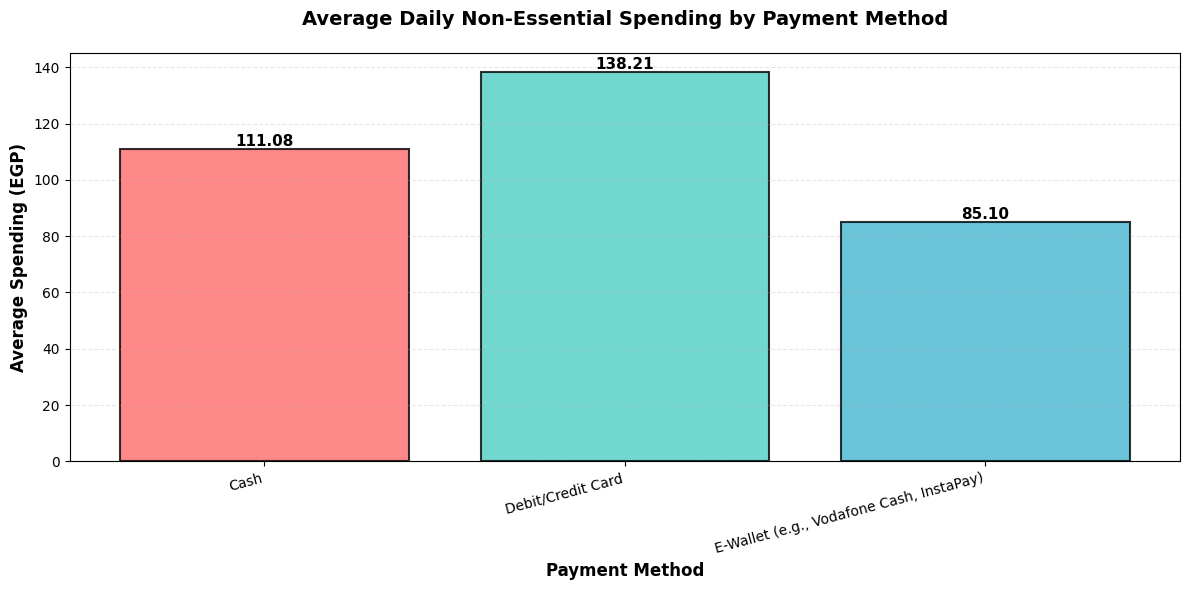


Interpretation:
This chart compares average daily spending on non-essential items across three payment methods.
Debit/Credit Card users spend the most (138.21 EGP on average),
followed by Cash users (111.08 EGP), and E-Wallet users (85.10 EGP).
This suggests that digital payment methods (especially cards) may encourage higher spending on non-essential items.




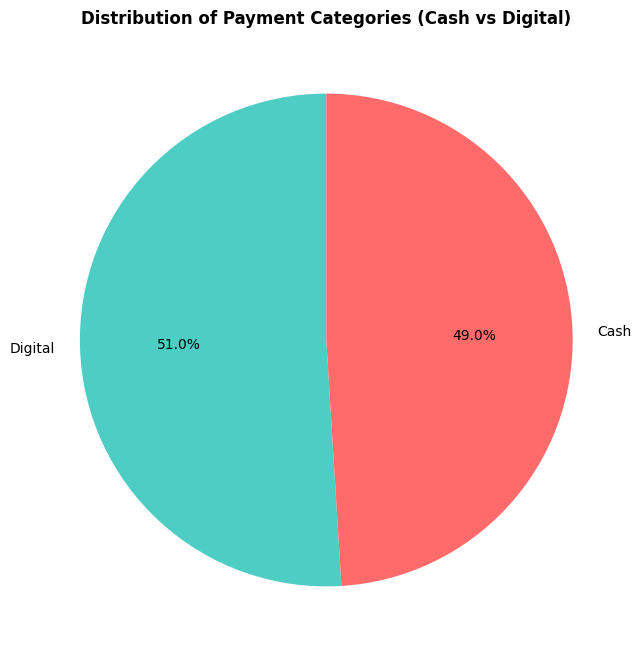

In [47]:
# Prepare data
spending_by_method = df.groupby('primary_payment_method')['daily_nonessential_spend_egp'].agg(['mean', 'median', 'std', 'count'])

# Create visualization
plt.figure(figsize=(12, 6))
bars = plt.bar(spending_by_method.index, spending_by_method['mean'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'], 
               edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Average Daily Non-Essential Spending by Payment Method', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Payment Method', fontsize=12, fontweight='bold')
plt.ylabel('Average Spending (EGP)', fontsize=12, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("This chart compares average daily spending on non-essential items across three payment methods.")
print(f"Debit/Credit Card users spend the most ({spending_by_method['mean'].max():.2f} EGP on average),")
print(f"followed by Cash users ({spending_by_method.loc['Cash', 'mean']:.2f} EGP), and E-Wallet users ({spending_by_method['mean'].min():.2f} EGP).")
print("This suggests that digital payment methods (especially cards) may encourage higher spending on non-essential items.")

print("\n" + "="*80 + "\n")

plt.figure(figsize=(8, 8))
payment_counts = df['payment_category'].value_counts()
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', colors=['#4ECDC4', '#FF6B6B'], startangle=90)
plt.title('Distribution of Payment Categories (Cash vs Digital)', fontweight='bold')
plt.savefig('pie_chart.png')
plt.show()

print("\n" + "="*80 + "\n")

7. Visualization 2: Emergent Purchases & Subscriptions by Payment Method

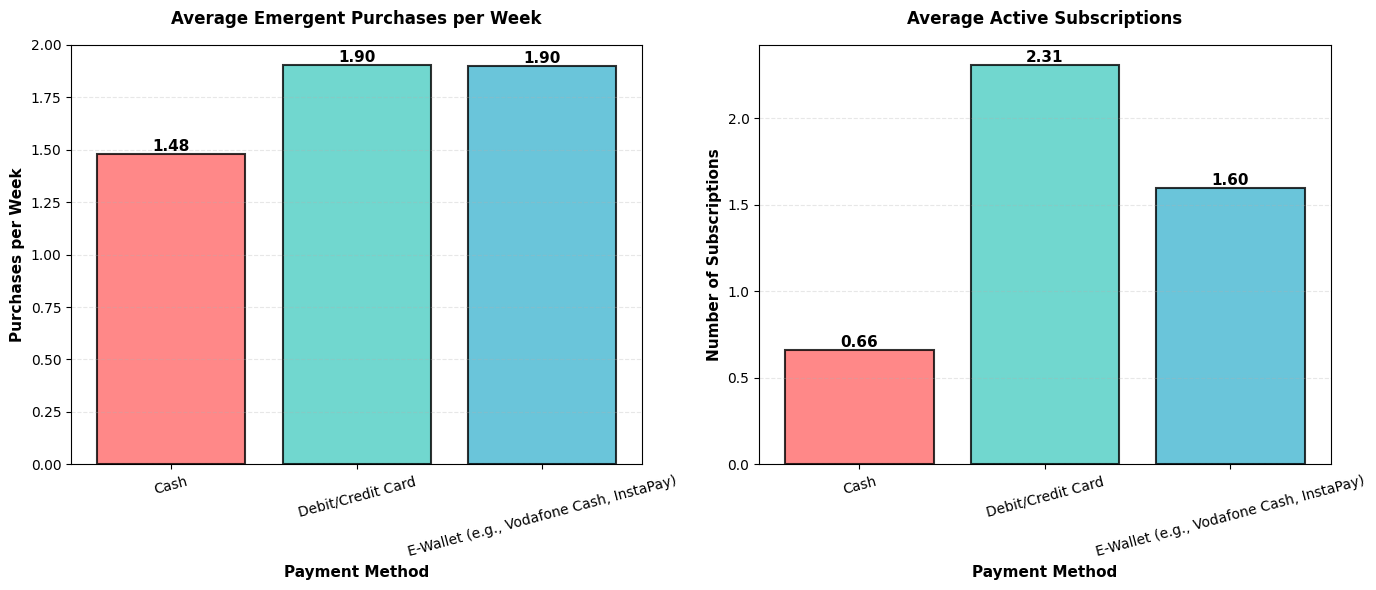


Interpretation:
LEFT CHART - Emergent Purchases:
Debit/Credit Card users make slightly more unplanned purchases (1.90/week)
compared to Cash users (1.48/week), suggesting impulsive buying behavior is higher with digital methods.

RIGHT CHART - Active Subscriptions:
Debit/Credit Card users have 3.5x more subscriptions (2.31) than Cash users (0.66),
indicating that recurring digital payments encourage subscription-based spending habits.




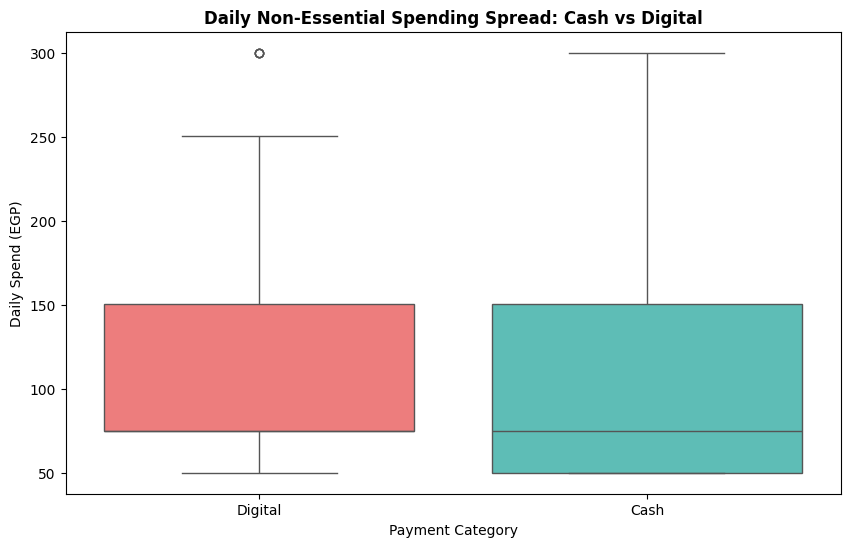

In [48]:
# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Emergent purchases
emergent_by_method = df.groupby('primary_payment_method')['emergent_purchases_per_week'].mean()
bars1 = axes[0].bar(emergent_by_method.index, emergent_by_method.values, 
                    color=['#FF6B6B', '#4ECDC4', '#45B7D1'], 
                    edgecolor='black', linewidth=1.5, alpha=0.8)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].set_title('Average Emergent Purchases per Week', fontsize=12, fontweight='bold', pad=15)
axes[0].set_xlabel('Payment Method', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Purchases per Week', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Subplot 2: Active subscriptions
subscriptions_by_method = df.groupby('primary_payment_method')['active_subscriptions_count'].mean()
bars2 = axes[1].bar(subscriptions_by_method.index, subscriptions_by_method.values, 
                    color=['#FF6B6B', '#4ECDC4', '#45B7D1'], 
                    edgecolor='black', linewidth=1.5, alpha=0.8)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].set_title('Average Active Subscriptions', fontsize=12, fontweight='bold', pad=15)
axes[1].set_xlabel('Payment Method', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Subscriptions', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("LEFT CHART - Emergent Purchases:")
print("Debit/Credit Card users make slightly more unplanned purchases (1.90/week)")
print("compared to Cash users (1.48/week), suggesting impulsive buying behavior is higher with digital methods.")
print("\nRIGHT CHART - Active Subscriptions:")
print("Debit/Credit Card users have 3.5x more subscriptions (2.31) than Cash users (0.66),")
print("indicating that recurring digital payments encourage subscription-based spending habits.")

print("\n" + "="*80 + "\n")

plt.figure(figsize=(10, 6))
sns.boxplot(x='payment_category', y='daily_nonessential_spend_egp', hue='payment_category', data=df, palette=['#FF6B6B', '#4ECDC4'], legend=False)
plt.title('Daily Non-Essential Spending Spread: Cash vs Digital', fontweight='bold')
plt.ylabel('Daily Spend (EGP)')
plt.xlabel('Payment Category')
plt.savefig('box_plot.png')
plt.show()

print("\n" + "="*80 + "\n")

In [49]:
cash_spend = df[df['payment_category'] == 'Cash']['daily_nonessential_spend_egp'].dropna()
digital_spend = df[df['payment_category'] == 'Digital']['daily_nonessential_spend_egp'].dropna()

t_stat, p_value = stats.ttest_ind(cash_spend, digital_spend, equal_var=False)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -0.7029845218929905
P-Value: 0.4853923273139985


8. Export Cleaned Dataset

In [50]:
# Export cleaned CSV
df.to_csv('project2_cleaned.csv', index=False)

print("Cleaned dataset exported successfully!")
print(f"\nDataset Summary:")
print(f"Total responses: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"Columns: {df.columns.tolist()}")
print("\nFile saved as: 'project2_cleaned.csv'")

Cleaned dataset exported successfully!

Dataset Summary:
Total responses: 51
Total columns: 11
Columns: ['age_group', 'gender', 'primary_payment_method', 'daily_nonessential_spend_egp', 'emergent_purchases_per_week', 'spending_tracking_frequency', 'spend_more_freely_digital', 'active_subscriptions_count', 'reasons_for_cash', 'reasons_for_digital', 'payment_category']

File saved as: 'project2_cleaned.csv'
